In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [2]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [3]:
ts = pd.read_csv('MOD-00680-3-11data.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31T18:59:39Z,5.994,0.655,0.205,0.049,0.032,0.010,6.214,915.842,26.285,2.634,30.679,50.3,-0.3
1,2025-12-31T18:58:39Z,6.468,0.764,0.280,0.051,0.046,0.030,6.855,973.063,24.489,2.764,32.084,50.5,-0.4
2,2025-12-31T18:57:39Z,6.272,0.729,0.231,0.060,0.029,0.019,7.400,828.224,24.855,2.634,31.378,50.4,-0.4
3,2025-12-31T18:56:39Z,5.740,0.710,0.181,0.061,0.035,0.019,8.131,776.642,25.938,2.635,31.386,50.2,-0.4
4,2025-12-31T18:55:39Z,6.041,0.714,0.229,0.063,0.039,0.017,6.523,798.044,24.821,2.763,31.602,50.7,-0.4


In [4]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31 18:59:39,5.994,0.655,0.205,0.049,0.032,0.010,6.214,915.842,26.285,2.634,30.679,50.3,-0.3
1,2025-12-31 18:58:39,6.468,0.764,0.280,0.051,0.046,0.030,6.855,973.063,24.489,2.764,32.084,50.5,-0.4
2,2025-12-31 18:57:39,6.272,0.729,0.231,0.060,0.029,0.019,7.400,828.224,24.855,2.634,31.378,50.4,-0.4
3,2025-12-31 18:56:39,5.740,0.710,0.181,0.061,0.035,0.019,8.131,776.642,25.938,2.635,31.386,50.2,-0.4
4,2025-12-31 18:55:39,6.041,0.714,0.229,0.063,0.039,0.017,6.523,798.044,24.821,2.763,31.602,50.7,-0.4


## Full Timeseries Plot

In [5]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-03-31,26.623812,5.199471,1.626987,0.508721,0.642392,0.491783,10.365142,904.597887,34.181296,2.423258,29.515454,85.576250,16.154167
2025-04-01,5.235414,0.802439,0.230033,0.057877,0.058153,0.035727,2.525832,672.030911,44.249232,2.173004,15.047068,46.614375,12.028333
2025-04-02,4.412448,0.826842,0.412734,0.164140,0.215137,0.154872,4.331127,780.377099,46.927803,2.045450,23.708031,42.112431,8.036181
2025-04-03,24.347511,4.824735,1.418843,0.438004,0.606451,0.494205,13.620967,894.914933,31.301197,2.405467,25.373945,80.040625,15.018333
2025-04-04,5.459592,0.641356,0.225500,0.069667,0.084639,0.058848,4.658168,732.429773,41.358316,2.050585,15.506378,45.745764,20.348264


In [6]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-03-31,26.623812,5.199471,1.626987,0.508721,0.642392,0.491783,10.365142,904.597887,34.181296,2.423258,29.515454,85.576250,16.154167,6.570030
2025-04-01,5.235414,0.802439,0.230033,0.057877,0.058153,0.035727,2.525832,672.030911,44.249232,2.173004,15.047068,46.614375,12.028333,3.596987
2025-04-02,4.412448,0.826842,0.412734,0.164140,0.215137,0.154872,4.331127,780.377099,46.927803,2.045450,23.708031,42.112431,8.036181,4.568978
2025-04-03,24.347511,4.824735,1.418843,0.438004,0.606451,0.494205,13.620967,894.914933,31.301197,2.405467,25.373945,80.040625,15.018333,8.626051
2025-04-04,5.459592,0.641356,0.225500,0.069667,0.084639,0.058848,4.658168,732.429773,41.358316,2.050585,15.506378,45.745764,20.348264,5.448432


<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_526/4292842166.py:47: SyntaxWarning: invalid escape sequence '\m'
  ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}]",fontsize=14)


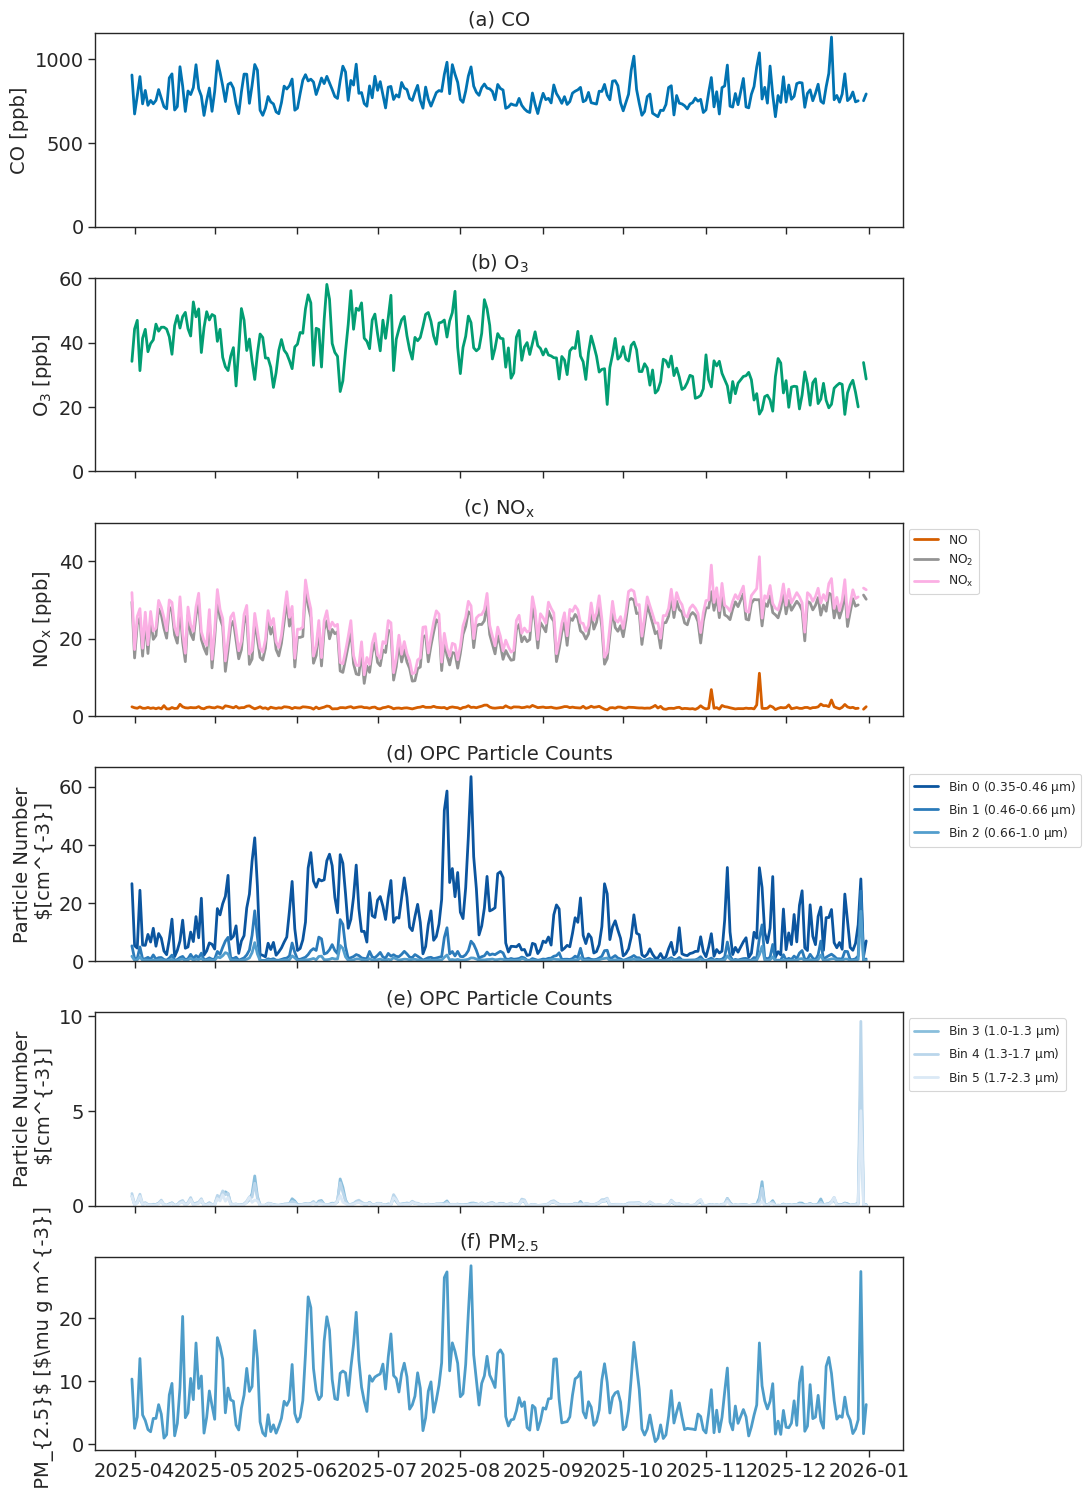

In [7]:
import os

# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 2nd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


# plot the OPC bins on the 5th and 6th rows
ax[3].plot(ts_day['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(ts_day['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(ts_day['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(ts_day['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(ts_day['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(ts_day['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(ts_day['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}]",fontsize=14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) OPC Particle Counts", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

os.makedirs('MOD-00680', exist_ok=True)
fig.savefig('MOD-00680/timeseries_MOD-000680.png')

## Dirunal Plots

In [8]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-03-31 20:00:00,28.588500,3.359517,1.366983,0.507983,0.700850,0.543117,13.229650,953.243883,28.708133,1.920983,32.471133,80.503333,16.081667
2025-03-31 21:00:00,32.171683,5.784067,1.842233,0.595817,0.802333,0.671783,12.585583,928.130450,30.240550,2.501750,30.877233,87.048333,15.890000
2025-03-31 22:00:00,31.801967,8.778400,2.456433,0.698250,0.807183,0.581800,11.275933,988.388650,28.374217,2.809300,34.848500,88.700000,16.345000
2025-03-31 23:00:00,13.933100,2.875900,0.842300,0.232833,0.259200,0.170433,4.369400,748.628567,49.402283,2.461000,19.864950,86.053333,16.300000
2025-04-01 00:00:00,17.398833,3.716367,1.093433,0.298667,0.322050,0.212067,5.835600,728.893867,46.853833,2.434017,26.581667,85.473333,15.833333


In [9]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-03-31 20:00:00,28.588500,3.359517,1.366983,0.507983,0.700850,0.543117,13.229650,953.243883,28.708133,1.920983,32.471133,80.503333,16.081667,8.789599
2025-03-31 21:00:00,32.171683,5.784067,1.842233,0.595817,0.802333,0.671783,12.585583,928.130450,30.240550,2.501750,30.877233,87.048333,15.890000,8.745164
2025-03-31 22:00:00,31.801967,8.778400,2.456433,0.698250,0.807183,0.581800,11.275933,988.388650,28.374217,2.809300,34.848500,88.700000,16.345000,8.417278
2025-03-31 23:00:00,13.933100,2.875900,0.842300,0.232833,0.259200,0.170433,4.369400,748.628567,49.402283,2.461000,19.864950,86.053333,16.300000,6.293361
2025-04-01 00:00:00,17.398833,3.716367,1.093433,0.298667,0.322050,0.212067,5.835600,728.893867,46.853833,2.434017,26.581667,85.473333,15.833333,6.693035


In [10]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-03-31 20:00:00,28.588500,3.359517,1.366983,0.507983,0.700850,0.543117,13.229650,953.243883,28.708133,1.920983,32.471133,80.503333,16.081667,8.789599,20
2025-03-31 21:00:00,32.171683,5.784067,1.842233,0.595817,0.802333,0.671783,12.585583,928.130450,30.240550,2.501750,30.877233,87.048333,15.890000,8.745164,21
2025-03-31 22:00:00,31.801967,8.778400,2.456433,0.698250,0.807183,0.581800,11.275933,988.388650,28.374217,2.809300,34.848500,88.700000,16.345000,8.417278,22
2025-03-31 23:00:00,13.933100,2.875900,0.842300,0.232833,0.259200,0.170433,4.369400,748.628567,49.402283,2.461000,19.864950,86.053333,16.300000,6.293361,23
2025-04-01 00:00:00,17.398833,3.716367,1.093433,0.298667,0.322050,0.212067,5.835600,728.893867,46.853833,2.434017,26.581667,85.473333,15.833333,6.693035,0


In [11]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,
00:00,12.412295,2.209563,0.668135,0.162321,0.157367,0.093575,7.321811,810.666821,33.875974,2.201318,23.864498,62.702649,16.655430,6.630535
01:00,12.284958,2.126041,0.630576,0.150832,0.148045,0.092502,7.000777,791.082370,33.027807,2.232774,23.821316,64.160818,16.248321,6.549507
02:00,12.229666,2.016278,0.573131,0.137438,0.139547,0.092370,6.713846,775.885653,32.346319,2.214517,23.541565,65.468516,15.856034,6.475772
03:00,12.564635,2.072301,0.574499,0.137300,0.140760,0.094011,6.676234,768.270581,31.283609,2.113849,23.423209,66.718880,15.619211,6.482731
04:00,12.588808,2.174003,0.620943,0.149643,0.147806,0.094127,6.511469,763.166464,30.320545,2.162513,23.489188,67.902203,15.290531,6.445597
05:00,13.000427,2.286313,0.663779,0.161604,0.160201,0.097421,6.617420,771.873533,28.897452,2.131959,23.909146,68.902739,15.027873,6.488050
06:00,12.878135,2.240182,0.668753,0.169190,0.170281,0.103516,6.621553,792.407455,27.700897,2.089321,24.159858,68.842505,15.042745,6.488580
07:00,13.020351,2.171711,0.658144,0.175764,0.193192,0.118673,7.142647,820.465839,27.610055,2.554707,22.544207,64.386986,16.341661,6.601879
08:00,12.824069,1.990852,0.594299,0.156181,0.177734,0.116301,7.652629,804.218104,29.237626,2.808803,19.125931,56.765240,18.981950,6.702947


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_526/3170824870.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_526/3170824870.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r

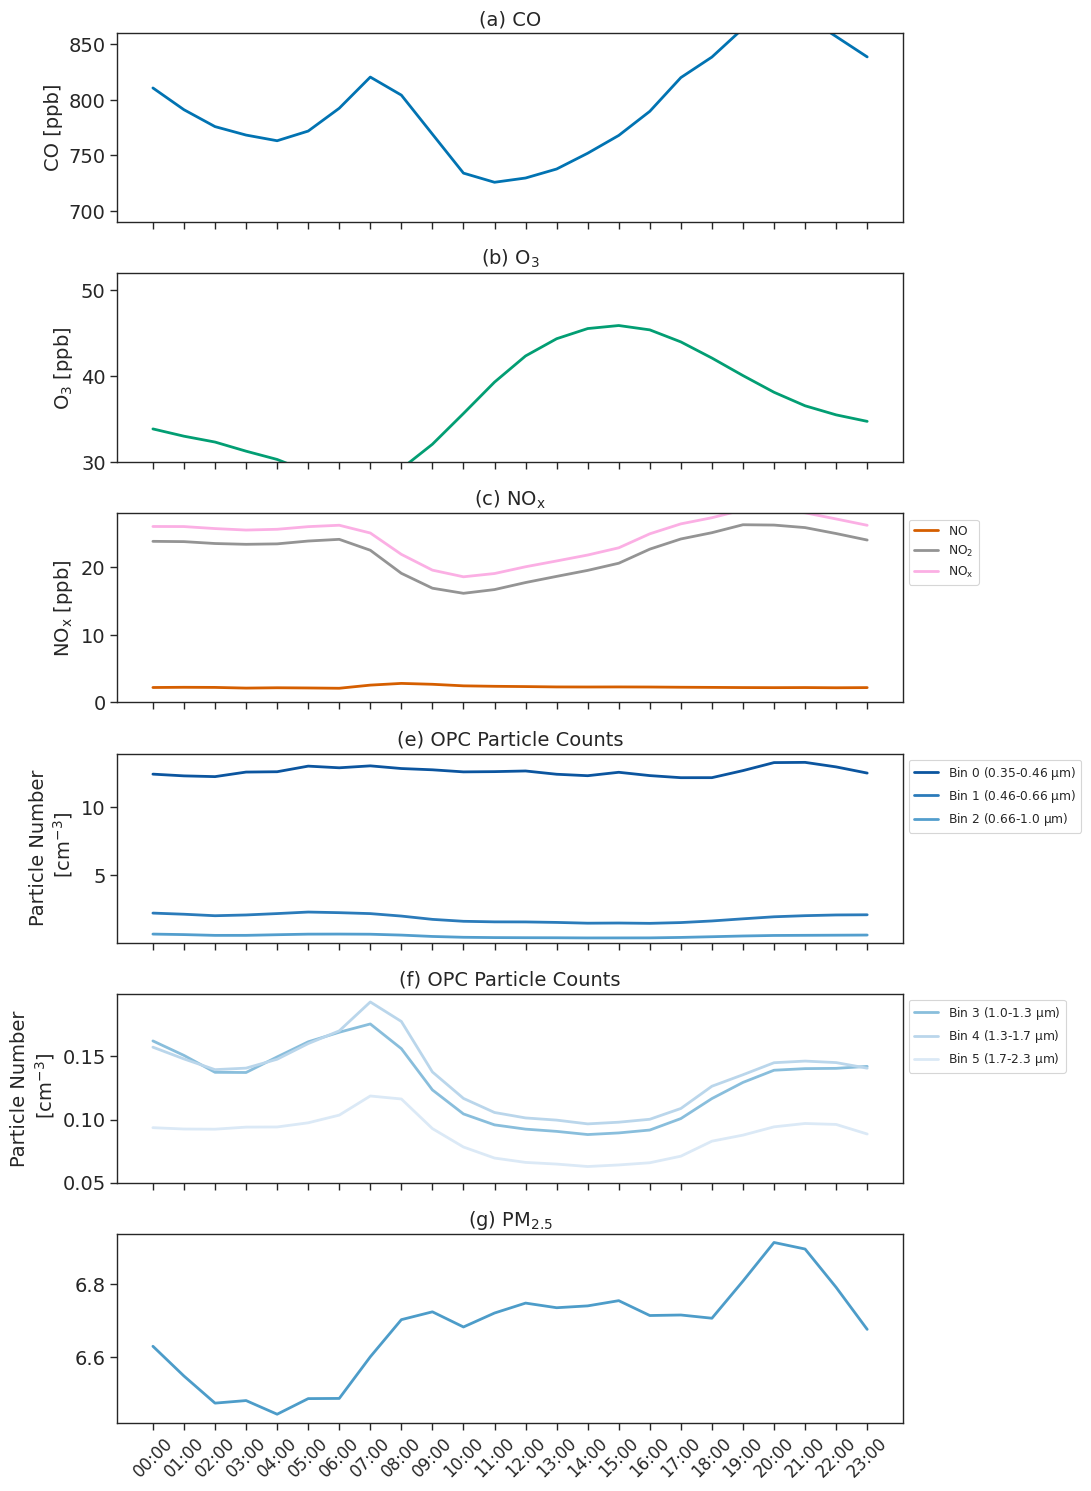

In [12]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(690, 860)

# plot the o3 on the first axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(30, 52)

#plot nox on the 2nd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 28)

# plot the OPC bins on the 3rd and 4th rows
ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(diurnal_data['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0.05, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(diurnal_data['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(diurnal_data['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(diurnal_data['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0.05, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(diurnal_data['pm25_c'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(e) OPC Particle Counts", fontsize=14)
ax[4].set_title("(f) OPC Particle Counts", fontsize=14)
ax[5].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# set x as hours
ax[5].set_xticks(range(24))
ax[5].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

fig.savefig('MOD-00680/dirunal_MOD-000680_allfeatures.png')

## Diurnal by Season

In [13]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [14]:
ts_hour = ts_hour.reset_index()

In [15]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,2025-03-31 20:00:00,28.588500,3.359517,1.366983,0.507983,0.700850,0.543117,13.229650,953.243883,28.708133,1.920983,32.471133,80.503333,16.081667,8.789599,20,Spring
1,2025-03-31 21:00:00,32.171683,5.784067,1.842233,0.595817,0.802333,0.671783,12.585583,928.130450,30.240550,2.501750,30.877233,87.048333,15.890000,8.745164,21,Spring
2,2025-03-31 22:00:00,31.801967,8.778400,2.456433,0.698250,0.807183,0.581800,11.275933,988.388650,28.374217,2.809300,34.848500,88.700000,16.345000,8.417278,22,Spring
3,2025-03-31 23:00:00,13.933100,2.875900,0.842300,0.232833,0.259200,0.170433,4.369400,748.628567,49.402283,2.461000,19.864950,86.053333,16.300000,6.293361,23,Spring
4,2025-04-01 00:00:00,17.398833,3.716367,1.093433,0.298667,0.322050,0.212067,5.835600,728.893867,46.853833,2.434017,26.581667,85.473333,15.833333,6.693035,0,Spring


In [16]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

bin0      bin1      bin2      bin3      bin4      bin5  \
Season Hour                                                                
Autumn 0      7.101787  1.268438  0.442269  0.115099  0.120612  0.079892   
       1      7.471339  1.113388  0.350098  0.088287  0.097528  0.073546   
       2      7.663937  1.114336  0.349535  0.089684  0.100377  0.076699   
       3      8.092438  1.162645  0.355828  0.091932  0.102954  0.078829   
       4      8.525674  1.391150  0.438485  0.110033  0.112843  0.076807   
...                ...       ...       ...       ...       ...       ...   
Winter 19    11.113381  1.575873  0.426594  0.097552  0.080815  0.047440   
       20    11.558124  1.636943  0.420968  0.096071  0.081042  0.047212   
       21    10.374961  1.529504  0.394954  0.091103  0.078903  0.046988   
       22    10.919443  1.718662  0.444796  0.104474  0.095461  0.058205   
       23    12.352810  2.248390  0.566929  0.122146  0.103748  0.061164   

                 pm25          co         o3        no        no2         rh  \
Season Hour                                                                    
Autumn 0     5.266970  781.082116  29.630112  2.274658  26.105365  62.220208   
       1     5.205389  773.557424  28.785068  2.423162  25.967252  64.195899   
       2     5.041279  763.769362  28.019141  2.420408  26.057329  65.549349   
       3     5.108382  760.333604  26.895710  2.157727  26.564326  66.720490   
       4     4.996187  760.381464  25.896602  2.361451  26.541649  68.085115   
...               ...         ...        ...       ...        ...        ...   
Winter 19    6.249829  841.239624  24.447492  2.294127  30.096210  57.196548   
       20    6.473434  830.580579  24.219673  2.333518  29.870757  57.563690   
       21    5.472713  813.388020  24.352399  2.312262  29.682376  57.855893   
       22    5.779565  801.396886  24.446080  2.266765  29.311502  59.161131   
       23    5.996217  804.740951  23.847532  2.381162  29.512169  60.716250   

                  temp    pm25_c  
Season Hour                       
Autumn 0     15.276723  5.937678  
       1     14.820058  5.943910  
       2     14.427126  5.907842  
       3     14.105471  5.939863  
       4     13.800709  5.923942  
...                ...       ...  
Winter 19     1.865179  5.439425  
       20     1.590238  5.501124  
       21     1.405060  5.200663  
       22     1.220536  5.314204  
       23     0.944405  5.402283  

[96 rows x 14 columns]

In [17]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,7.101787,1.268438,0.442269,0.115099,0.120612,0.079892,5.266970,781.082116,29.630112,2.274658,26.105365,62.220208,15.276723,5.937678
1,Autumn,1,7.471339,1.113388,0.350098,0.088287,0.097528,0.073546,5.205389,773.557424,28.785068,2.423162,25.967252,64.195899,14.820058,5.943910
2,Autumn,2,7.663937,1.114336,0.349535,0.089684,0.100377,0.076699,5.041279,763.769362,28.019141,2.420408,26.057329,65.549349,14.427126,5.907842
3,Autumn,3,8.092438,1.162645,0.355828,0.091932,0.102954,0.078829,5.108382,760.333604,26.895710,2.157727,26.564326,66.720490,14.105471,5.939863
4,Autumn,4,8.525674,1.391150,0.438485,0.110033,0.112843,0.076807,4.996187,760.381464,25.896602,2.361451,26.541649,68.085115,13.800709,5.923942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Winter,19,11.113381,1.575873,0.426594,0.097552,0.080815,0.047440,6.249829,841.239624,24.447492,2.294127,30.096210,57.196548,1.865179,5.439425
92,Winter,20,11.558124,1.636943,0.420968,0.096071,0.081042,0.047212,6.473434,830.580579,24.219673,2.333518,29.870757,57.563690,1.590238,5.501124
93,Winter,21,10.374961,1.529504,0.394954,0.091103,0.078903,0.046988,5.472713,813.388020,24.352399,2.312262,29.682376,57.855893,1.405060,5.200663
94,Winter,22,10.919443,1.718662,0.444796,0.104474,0.095461,0.058205,5.779565,801.396886,24.446080,2.266765,29.311502,59.161131,1.220536,5.314204


In [18]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [19]:
autumn_diurnal

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,7.101787,1.268438,0.442269,0.115099,0.120612,0.079892,5.266970,781.082116,29.630112,2.274658,26.105365,62.220208,15.276723,5.937678
01:00,Autumn,1,7.471339,1.113388,0.350098,0.088287,0.097528,0.073546,5.205389,773.557424,28.785068,2.423162,25.967252,64.195899,14.820058,5.943910
02:00,Autumn,2,7.663937,1.114336,0.349535,0.089684,0.100377,0.076699,5.041279,763.769362,28.019141,2.420408,26.057329,65.549349,14.427126,5.907842
03:00,Autumn,3,8.092438,1.162645,0.355828,0.091932,0.102954,0.078829,5.108382,760.333604,26.895710,2.157727,26.564326,66.720490,14.105471,5.939863
04:00,Autumn,4,8.525674,1.391150,0.438485,0.110033,0.112843,0.076807,4.996187,760.381464,25.896602,2.361451,26.541649,68.085115,13.800709,5.923942
05:00,Autumn,5,9.128074,1.701110,0.533025,0.127756,0.124158,0.075926,4.967347,762.542841,24.508810,2.282573,26.896182,69.324861,13.560943,5.933113
06:00,Autumn,6,9.307819,1.702506,0.562229,0.140131,0.132540,0.077335,4.866563,778.329476,23.251008,2.078352,27.215006,70.493113,13.184253,5.912283
07:00,Autumn,7,9.283865,1.509843,0.472829,0.119340,0.121955,0.075025,5.360281,825.743979,23.216312,2.789003,26.703853,67.598712,14.194848,6.040475
08:00,Autumn,8,8.514969,1.245646,0.400139,0.104075,0.111498,0.070643,5.915119,815.325704,24.510930,3.039050,21.535922,57.870511,17.311761,6.128186
09:00,Autumn,9,7.979238,1.159169,0.399509,0.105750,0.115306,0.071302,6.104324,766.047125,27.233724,3.042017,18.711834,50.527860,20.004489,6.142982


In [20]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_526/3328282612.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_526/3328282612.py:41: SyntaxWarning: invalid escape sequence '\m'


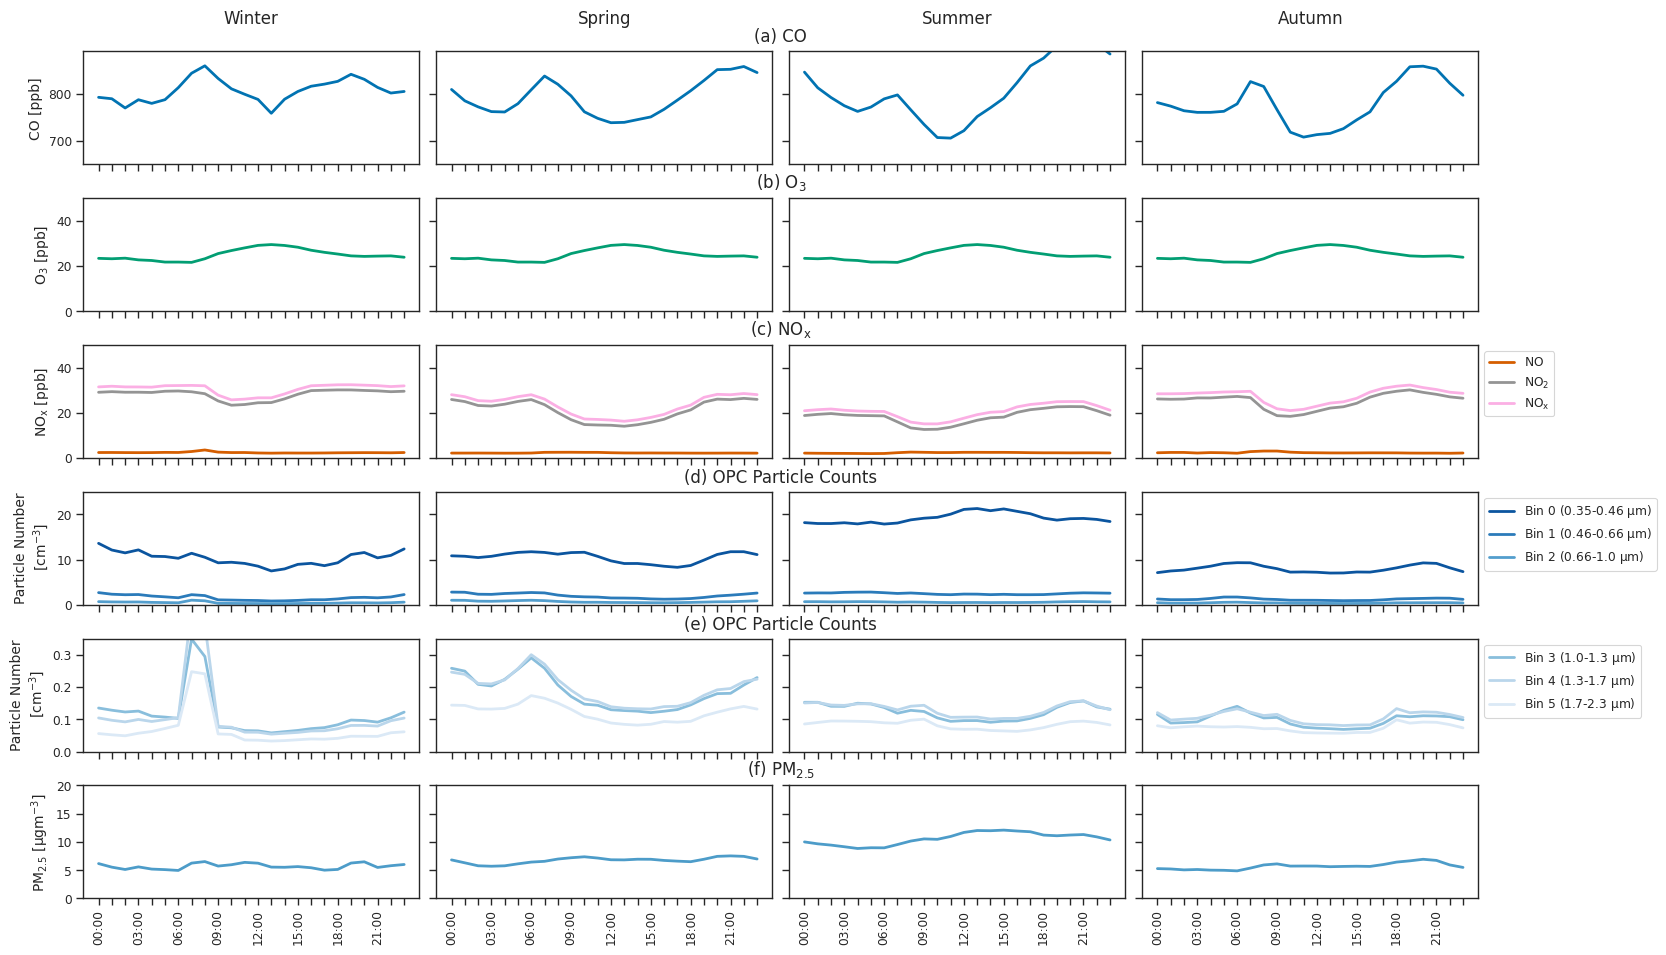

In [21]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)

    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(650, 890)
    ax[0,i].set_xticks(range(0, 2))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 50)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))

    # plot the OPC bins on the 4th and 5th rows
    ax[3,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[3,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[3,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[3,i].set(ylim=(0, 25))
    ax[3,3].legend(fontsize = 14)
    sns.move_legend(ax[3,3], "upper left", bbox_to_anchor=(1, 1))

    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[4,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[4,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[4,i].set(ylim=(0, 0.35))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 6th row
    ax[5,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[5,i].plot(seasons_order[i]['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
    ax[5,i].set(ylim=(0, 20))
    ax[5,i].set_xticklabels(['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''], rotation=90)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(6):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    row_titles = [
    "(a) CO",
    "(b) $O_3$",
    "(c) $NO_x$",
    "(d) OPC Particle Counts",
    "(e) OPC Particle Counts",
    "(f) $PM_{2.5}$"
]

for r, title in enumerate(row_titles):

    # left and right subplot positions
    left = ax[r,0].get_position()
    right = ax[r,-1].get_position()

    # horizontal center between first and last column
    x_center = (left.x0 + right.x1) / 2

    # slightly above the row
    y_top = left.y1 + 0.005

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=12
    )

fig.savefig('MOD-00680/diurnal_by_season_MOD-000680.png')